In [1]:
import pandas as pd

df = pd.read_csv('page.csv')
df.head()

,timestamp,id,group,action
0,2016-09-24 17:42:27.839496,804196,experiment,view
1,2016-09-24 19:19:03.542569,434745,experiment,view
2,2016-09-24 19:36:00.944135,507599,experiment,view
3,2016-09-24 19:59:02.646620,671993,control,view
4,2016-09-24 20:26:14.466886,536734,experiment,view


In [3]:
# Total Actions 
df["action"].count()

np.int64(8188)

In [7]:
# Total unique users 
df["id"].nunique()

6328

In [11]:
# sizes of the control and experiment groups (i.e., the number of unique users in each group)

df[df["group"] == "experiment"]["id"].nunique(), df[df["group"] == "control"]["id"].nunique()


(2996, 3332)

How long did the experiment run?

In [13]:
df.head(1)

,timestamp,id,group,action
0,2016-09-24 17:42:27.839496,804196,experiment,view


In [14]:
df.tail(1)

,timestamp,id,group,action
8187,2017-01-18 10:24:08.629327,461199,control,view


In [ ]:
# converting time stamp to date time
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [ ]:
# using iloc to subtract index locations of the start and end to get the duration
duration = df["timestamp"].iloc[-1] - df["timestamp"].iloc[1]

In [18]:
duration

Timedelta('115 days 15:05:05.086758')

In [19]:
# What are the unique actions?
df["action"].unique()

array(['view', 'click'], dtype=object)

Why use click through rates? What are the click thru rates? What are the null and alternate hypothesis?

In [20]:
# Use click through to determine unqiue visitors vs unqiue clicks

In [21]:
control_df = df[df["group"]=="control"]

In [28]:
control_counter = control_df[control_df["action"]=="click"].id.nunique() / control_df[control_df["action"]=="view"].id.nunique()

In [31]:
control_counter = control_df.query('action=="click"').id.nunique() / control_df.query('action=="view"').id.nunique()

In [32]:
control_counter

0.2797118847539016

In [33]:
exp_df = df[df["group"]=="experiment"]

In [34]:
exp_counter = exp_df.query('action=="click"').id.nunique() / exp_df.query('action=="view"').id.nunique()

In [35]:
exp_counter

0.3097463284379172

In [36]:
observed_diff = exp_counter - control_counter

In [37]:
observed_diff

0.030034443684015644

In [40]:
# Boostrap the groups to see the distribution 

diffs = []

for i in range(10000):
    samp = df.sample(df.shape[0],replace=True)
    control_df = samp.query('group == "control"')
    exp_df = samp.query('group=="experiment"')
    control_ctr = control_df.query('action == "click"').id.nunique() / control_df.query('action == "view"').id.nunique()
    experiment_ctr = exp_df.query('action == "click"').id.nunique() / exp_df.query('action == "view"').id.nunique()
    diffs.append(experiment_ctr - control_ctr)

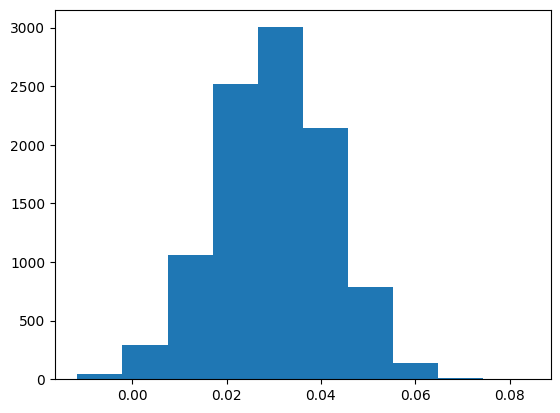

In [44]:
import matplotlib.pyplot as plt
import numpy as np
plt.hist(diffs);

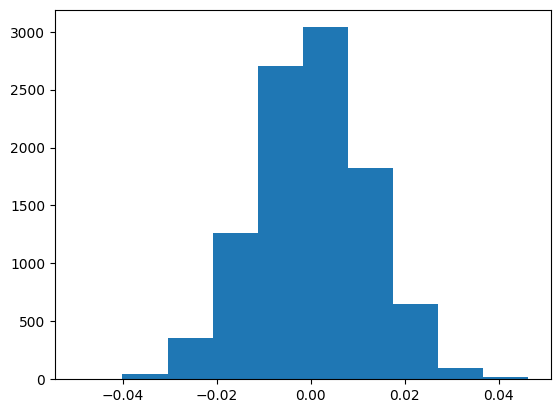

In [45]:
diffs = np.array(diffs)
null_vals = np.random.normal(0, diffs.std(), diffs.size)
plt.hist(null_vals);

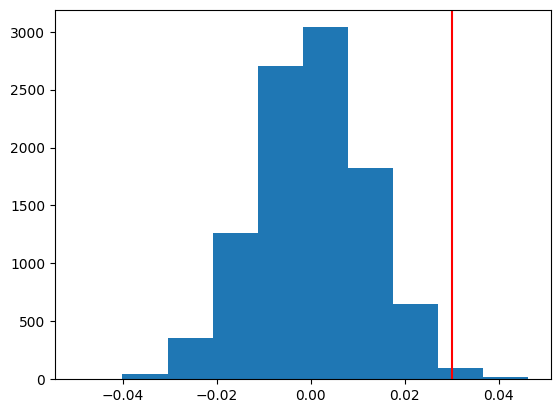

In [47]:
plt.hist(null_vals);
plt.axvline(x=observed_diff, color='red');

In [48]:
(null_vals > observed_diff).mean()

np.float64(0.0072)